# Student Performance Indicator

#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Import the dataset as a pandas dataframe

In [4]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing Values

In [5]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

There has no missing values in the dataset

### 3.2 Check duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

#### There has no any duplicates values

### 3.3 Check Data type

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 3.4 Check the unique values of all columns

In [12]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check the statistics of the dataset

In [13]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.7 Exploring the data

In [14]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [19]:
print('Categories in "gender" column: ', end=' ')
print(np.array(df['gender'].unique()))

print('Categories in "race_ethnicity" column: ', end=' ')
print(np.array(df['race_ethnicity'].unique()))

print('Categories in "parental_level_of_education" column: ', end=' ')
print(np.array(df['parental_level_of_education'].unique()))

print('Categories in "lunch" column: ', end=' ')
print(np.array(df['lunch'].unique()))

print('Categories in "test_preparation_course" column: ', end=' ')
print(np.array(df['test_preparation_course'].unique()))

Categories in "gender" column:  ['female' 'male']
Categories in "race_ethnicity" column:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in "parental_level_of_education" column:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in "lunch" column:  ['standard' 'free/reduced']
Categories in "test_preparation_course" column:  ['none' 'completed']


In [21]:
numerical_features = [features for features in df.columns if df[features].dtypes != 'str']
categorical_features = [features for features in df.columns if df[features].dtypes == 'str']

print('We have {} numerical features: {}'.format(len(numerical_features), numerical_features))
print('We have {} categorical features: {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### 3.8 Adding columns 'Total Score', 'Average'

In [22]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [23]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score'] / 3
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [26]:
math_full = df[df['math_score'] == 100]['average_score'].count()
reading_full = df[df['reading_score'] == 100]['average_score'].count()
writing_full = df[df['writing_score'] == 100]['average_score'].count()

print(f'Number of students with full marks in math_score: {math_full}')
print(f'Number of students with full marks in reading_score: {reading_full}')
print(f'Number of students with full marks in writing_score: {writing_full}')

Number of students with full marks in math_score: 7
Number of students with full marks in reading_score: 17
Number of students with full marks in writing_score: 14


In [27]:
math_less_20 = df[df['math_score'] <= 20]['average_score'].count()
reading_less_20 = df[df['reading_score'] <= 20]['average_score'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average_score'].count()

print(f'Number of students with math_score less than 20: {math_less_20}')
print(f'Number of students with reading_score less than 20: {reading_less_20}')
print(f'Number of students with writing_score less than 20: {writing_less_20}')

Number of students with math_score less than 20: 4
Number of students with reading_score less than 20: 1
Number of students with writing_score less than 20: 3


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

<Axes: xlabel='average_score', ylabel='Count'>

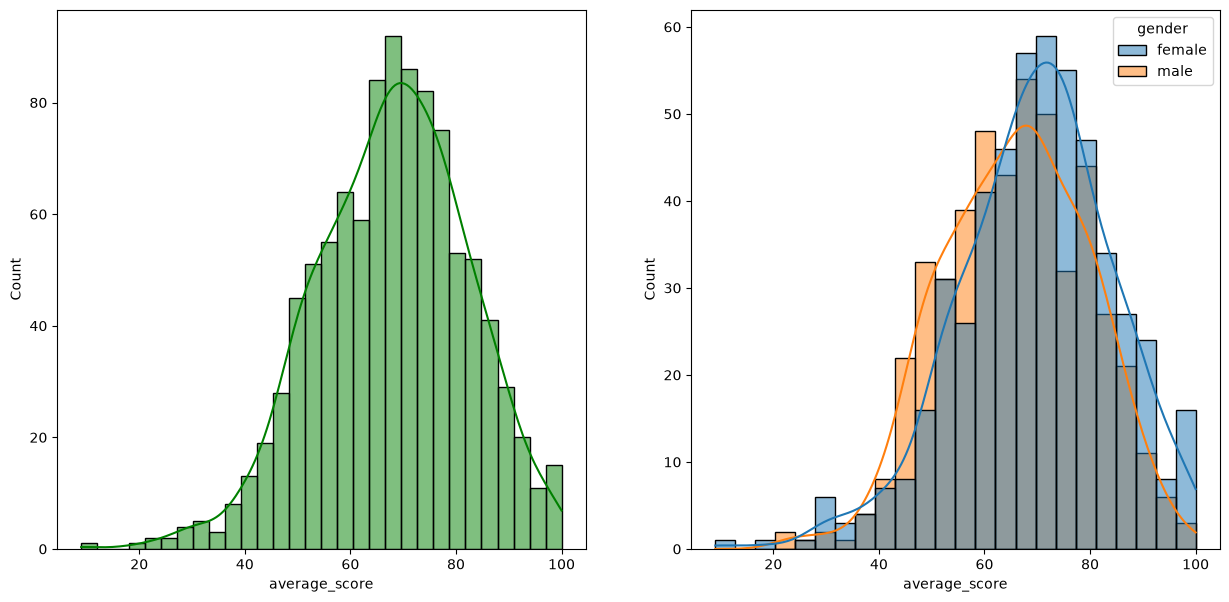

In [ ]:
# histogram w.r.t average_score

fig, axs = plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='average_score', kde=True, bins=30, color='g')
plt.subplot(122)
sns.histplot(data=df, x='average_score', kde=True, hue='gender')

<Axes: xlabel='total_score', ylabel='Count'>

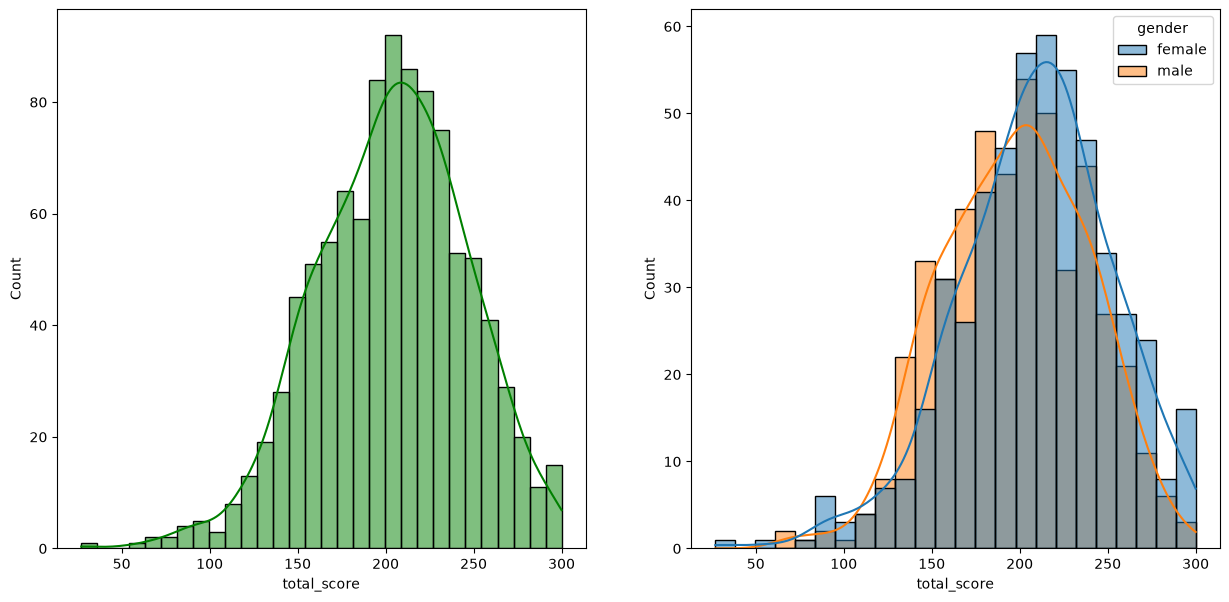

In [31]:
# histogram w.r.t total_score

fig, axs = plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='total_score', kde=True, bins=30, color='g')
plt.subplot(122)
sns.histplot(data=df, x='total_score', kde=True, hue='gender')

#####  Insights
- Female students tend to perform well then male students.

<Axes: xlabel='average_score', ylabel='Count'>

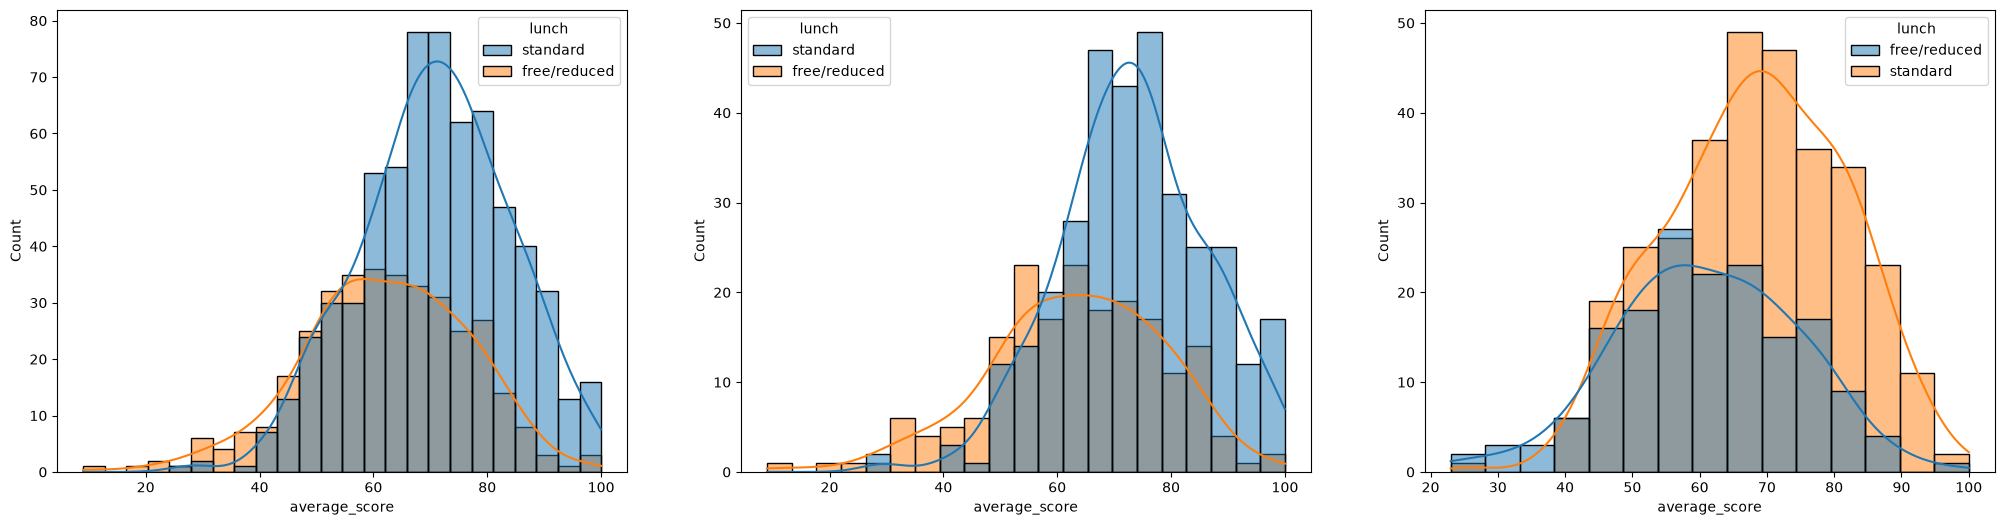

In [33]:
plt.subplots(1, 3, figsize=(25,6))

plt.subplot(131)
sns.histplot(data=df, x='average_score', kde=True, hue='lunch')

plt.subplot(132)
sns.histplot(data=df[df['gender'] == 'female'], x='average_score', kde=True, hue='lunch')

plt.subplot(133)
sns.histplot(data=df[df['gender'] == 'male'], x='average_score', kde=True, hue='lunch')